## Comparative analysis for the baseline fitting of denatured and folded protein

In this notebook we fit the unfolded baseline to completly unfolded curves based on a temperature window of a set size from the high end of temperatures for curves of 330nm and 350nm. We compare two baseline fitting formulas, quadratic and exponential, and compare them for their ability to generalize to the whole curve. 

The data comes from *Fricke et al.*<sup>1</sup> 


<sup>1</sup> Fricke, Celia, et al. "On the thermal and chemical stability of DNAJB6b and its globular domains." Biophysical Chemistry 320 (2025): 107401.*

This notebook is possible thanks to the publication of the data and associated code.
See https://data.dtu.dk/articles/code/Fitting_of_thermal_and_chemical_denaturation/27679716

### Using the demo DSF data for evaluation of the two formulas

In [1]:
#imports for the plotting of pychemelt
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pychemelt import Monomer


def model(x, a, b, c=None, kind=None):
    """
    Encoding functions for baseline fitting
    """
    if kind == "linear":
        return a + x * b
    elif kind == "quadratic":
        return a + b*x + c*(x**2)
    elif kind == "exponential":
        return a + b * np.exp(-c * x)
    else:
        raise ValueError("Unknown model type")
    

def rmse(x1, x2):
    """
    Implementation of RMSE
    """
    return np.sqrt(np.mean((x1 - x2)**2))


#okabe ito colorblind friendly colorscheme
okabe_ito = {
    "black":       "#000000",
    "orange":      "#E69F00",
    "skyblue":     "#56B4E9",
    "bluishgreen": "#009E73",
    "yellow":      "#F0E442",
    "blue":        "#0072B2",
    "vermillion":  "#D55E00",
    "reddishpurple": "#CC79A7",
}

### Using the demo baseline and two curves without inflection points as comparison (highest denaturant concentration)

In [2]:
from dataclasses import dataclass

@dataclass
class pantasample:
    T: np.ndarray
    f330: np.ndarray
    f350: np.ndarray
    denaturant: float

df = pd.read_csv('../data/nanoDSF_B6.csv', sep = '\t')

# Denaturant concentrations in M
denaturants = [0, 0.08, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8, 5.2, 5.6, 6, 6.4]

B6 = [] # List for storing unfolding measurements
for i in range(18):

    temperature = df[df.columns[i*12]].values + 273.15  # Convert to Kelvin

    B6.append(pantasample(df[df.columns[i*12]].values, df[df.columns[i*12+9]].values, df[df.columns[i*12+5]].values, denaturants[i])) 

sample = Monomer()

signal_dic = {}
temp_dic = {}

# Create a signal matrix from each B6 f350 array
signal_matrix = np.array([b6.f350 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['350nm'] = signal_matrix
sample.temp_dic['350nm'] = temp_matrix

# Create a signal matrix from each B6 f330 array
signal_matrix = np.array([b6.f330 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['330nm'] = signal_matrix
sample.temp_dic['330nm'] = temp_matrix

conditions = [b6.denaturant for b6 in B6]
sample.conditions = conditions

sample.set_signal(['350nm','330nm'])

sample.set_denaturant_concentrations()
selected = [False] * 13 + [True] * 1 + [False] * 4
sample.select_conditions(selected,normalise_to_global_max=True)

print(sample.denaturant_concentrations)

[4.8]


### Using a dataset containing curves for the DNAJB6b dataset

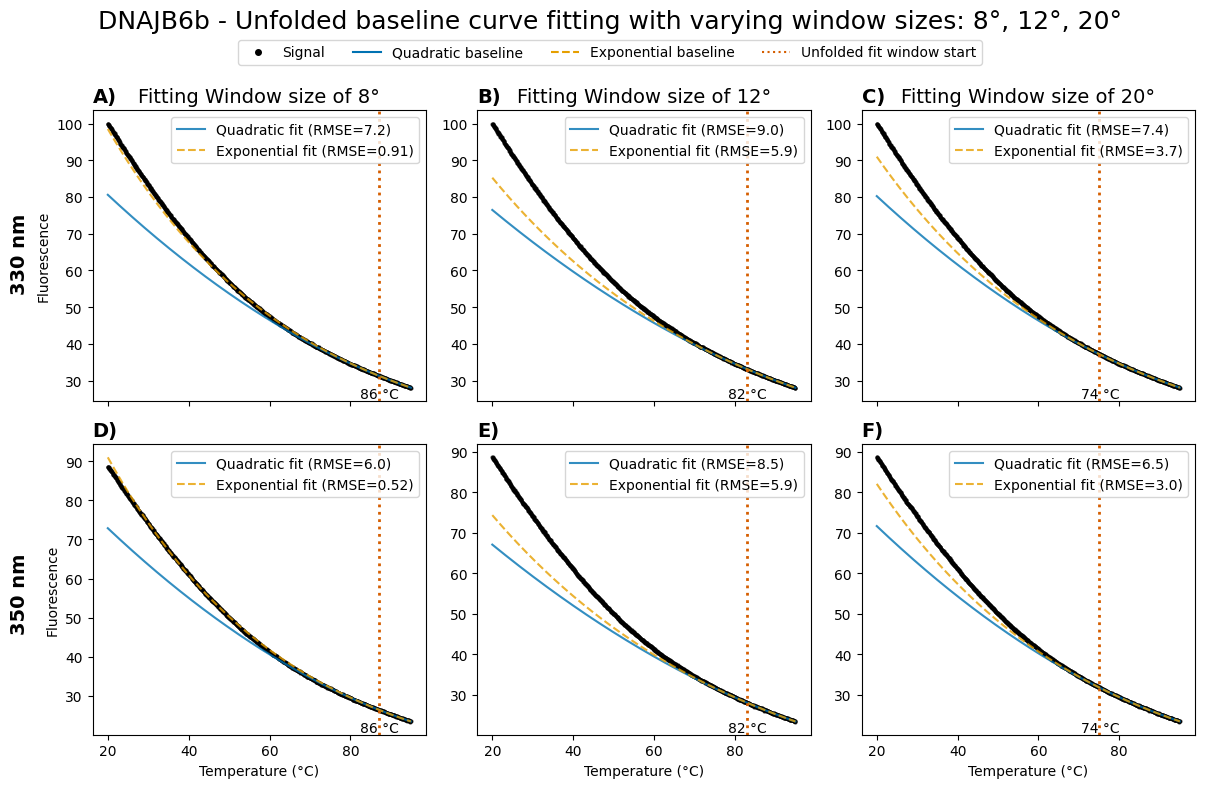

In [3]:
def unfolded_comp_fig(windows=[12]): 
    """
    Compare quadratic and exponential unfolded baseline fits for DSF data with an unfolded curve.

    This function estimates unfolded-state baselines using both quadratic and
    exponential models by fitting the curves to the data of the last °C of 
    different window sizes given in windows, 
    compares their performance using RMSE, and visualizes
    the results for two fluorescence signals (330 nm and 350 nm).

    Parameters
    ----------
    
    windows : int, optional, Default [12]
        Window sizes (in °C) used for fitting the unfolded baseline.
        This parameter defines the temperature range over which the baseline
        parameters are estimated. Default is [12].

    Returns
    -------
    fig: object
        The matplotlib figure object

    Notes
    -----
    - RMSE is computed between the measured fluorescence signal and the fitted
      baseline for each denaturant concentration and signal.
    - Temperatures are internally converted to Kelvin and referenced to 298 K
      before model evaluation.
    - A shared legend and figure-level title are used for visualization.


    """

    if not isinstance(windows, list):
        windows = [windows]

    fig, axes = plt.subplots(
    ncols=len(windows),
    nrows=2,
    figsize=(4 * len(windows), 8),
    sharex=True,
    )

    for j, ws in enumerate(windows):

        #fit the baselines as quadratic curve
        sample.estimate_baseline_parameters(
            native_baseline_type="linear",
            unfolded_baseline_type="quadratic",
            window_range_unfolded=ws
        )

        a_quas = sample.first_param_Us_per_signal
        b_quas = sample.second_param_Us_per_signal
        c_quas = sample.third_param_Us_per_signal

        #fit the baselines as exponential curve
        sample.estimate_baseline_parameters(
            native_baseline_type="linear",
            unfolded_baseline_type="exponential",
            window_range_unfolded=ws
        )

        a_exps = sample.first_param_Us_per_signal
        b_exps = sample.second_param_Us_per_signal
        c_exps = sample.third_param_Us_per_signal

        #assigning preprocessed signal and temperature for plotting
        temperature = sample.temp_lst_multiple[0][0]     
        fluorescences = sample.signal_lst_multiple  

        
        #using the removed reference temperature for plotting
        temperature_K = temperature + 273.15
        temperature_K_ref = temperature_K - 298

        #creating all formula results for comparison and plots

        T_window_start = temperature.max() - ws

        for i in range(2):    # 330nm and 350nm

            if len(windows) == 1:
                ax = axes[i]
            else:
                ax = axes[i, j]

            qua_bl = model(temperature_K_ref,
                a_quas[i][0],
                b_quas[i][0],
                c_quas[i][0],
                kind="quadratic")


            exp_bl = model(temperature_K_ref,
                a_exps[i][0],
                b_exps[i][0],
                c_exps[i][0],
                kind="exponential")



            #plotting the results
            ax.scatter(
                temperature,
                fluorescences[i][0],
                s=4,
                color=okabe_ito["black"],
                alpha=0.7,
            )

            ax.plot(
                temperature,
                qua_bl,
                color=okabe_ito["blue"],
                alpha=0.8,
                label=f"Quadratic fit (RMSE={rmse(fluorescences[i][0], qua_bl):.2})",
            )

            ax.plot(
                temperature,
                exp_bl,
                color=okabe_ito["orange"],
                linestyle="--",
                alpha=0.8,
                label=f"Exponential fit (RMSE={rmse(fluorescences[i][0], exp_bl):.2})",
            )

            ax.axvline(
                T_window_start,
                color=okabe_ito["vermillion"],
                linestyle=":",
                linewidth=2,
            )

            ax.text(
                T_window_start+5,
                ax.get_ylim()[0],                
                f"{int(T_window_start)} °C",
                color="black",
                ha="right",
                va="bottom",
                fontsize=10,
            )           

            if i == 0:
                ax.set_title(f"Fitting Window size of {ws}°", fontsize=14)

            # panel label
            if len(windows) == 1:
                label_idx = i
            else:
                label_idx = i * axes.shape[1] + j


            ax.set_title(f"{string.ascii_uppercase[label_idx]})", loc="left", fontsize=14,
                fontweight="bold",)


            if j == 0:
                ax.set_ylabel("Fluorescence")

            ax.legend(loc='upper right')
            #ax.grid(True)

            if i == 1:
                ax.set_xlabel("Temperature (°C)")



        # manual legend (once)
        handles = [
            plt.Line2D([0], [0], color=okabe_ito["black"], linestyle='None', marker='o', markersize=4, label="Signal"),
            plt.Line2D([0], [0], color=okabe_ito["blue"], label="Quadratic baseline"),
            plt.Line2D([0], [0], color=okabe_ito["orange"], linestyle="--", label="Exponential baseline"),
            plt.Line2D([0], [0], color=okabe_ito["vermillion"], linestyle=":", label="Unfolded fit window start"),
        ]

    ws_str = [str(x)for x in windows]

    fig.suptitle("DNAJB6b - Unfolded baseline curve fitting with varying window sizes: " + "°, ".join(ws_str) + "°", fontsize=18)
    fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.95))
    
    # Row labels for signals
    row_labels = ["330 nm", "350 nm"]

    # Y positions are in figure coordinates (0–1)
    for i, label in enumerate(row_labels):
        fig.text(
            0.0,                       # x position (left margin)
            0.675 - i * 0.425,             # y position (top to bottom)
            label,
            va="center",
            ha="left",
            rotation=90,
            fontsize=14,
            fontweight="bold",
        )
    
    fig.tight_layout(rect=[0.01, 0, 1, 0.95])
    
    
    return fig


#using unfolded curves of the DNAJB6b dataset

# using the default window size

fig = unfolded_comp_fig(windows=[8, 12, 20])

fig.savefig("1b_exp_quad_fit_analysis_DNAJB6b.png")